## Material Data
Redefined Magnetic Performance Factor Considering Dielectric Effects in Ferrite Cores

In [29]:
"""Example file to show how to get different material data."""
import logging
import numpy as np

from meta import paths

import materialdatabase as mdb
from materialdatabase.processing.utils.constants import epsilon_0, mu_0

# configure logging to show femmt terminal output
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

# Plot settings
plot = True
path2grid_plot = paths.grafics

# Save settings
save_to_file = True
path2grid_export = paths.material_data

# init a material database instance
mdb_data = mdb.Data()

### N49

INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\N49.csv.
c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:142: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))
INFO:[1.25973768e+00 2.41450212e+00 7.16875880e+01 9.78574824e-15
 2.51299607e+00 1.27952500e+01 4.85866609e-01 5.08175609e-03]
INFO:MRE = 0.22552945248294398
INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\N49.csv.


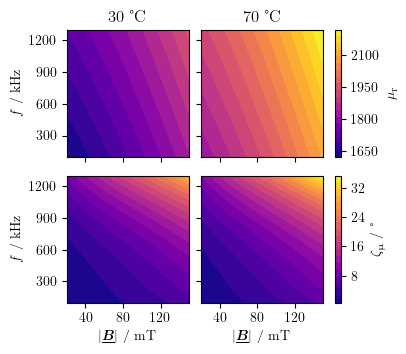

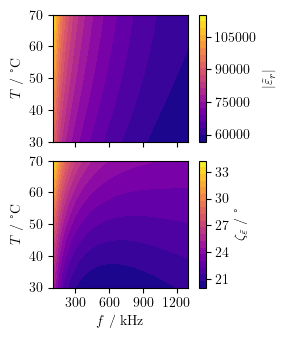

Data exported to N:\groups\lea\data\Employees\tpiepe\Simulationen\TPEL26\materials
 - - - - - - - - - - - - - - -
f = 100000.0
half wavelength: 110.8 mm

mu_N49_lin real part: 1816
mu_N49_lin imaginary part (positive loss form): 42

eps_N49_lin real part: 93410
eps_N49_lin imaginary part (positive loss form): 57049

|mu_N49_lin|: 1817
phase(mu_N49_lin) in deg (positive loss form): 1.3

|eps_N49_lin|: 109454
phase(eps_N49_lin) in deg (positive loss form): 31.4

 - - - - - - - - - - - - - - -
f = 500000.0
half wavelength: 26.6 mm

mu_N49_lin real part: 1849
mu_N49_lin imaginary part (positive loss form): 91

eps_N49_lin real part: 66257
eps_N49_lin imaginary part (positive loss form): 28845

|mu_N49_lin|: 1851
phase(mu_N49_lin) in deg (positive loss form): 2.8

|eps_N49_lin|: 72264
phase(eps_N49_lin) in deg (positive loss form): 23.5

 - - - - - - - - - - - - - - -
f = 1000000.0
half wavelength: 14.3 mm

mu_N49_lin real part: 1877
mu_N49_lin imaginary part (positive loss form): 259

eps_

In [30]:
material_name = mdb.Material.N49
probe_codes = None
# probe_codes = ["R16x9.6x6.3"]
# probe_codes = ["65Y"]
permeability_data_source = mdb.DataSource.LEA_MTB
permittivity_data_source = mdb.DataSource.LEA_MTB

# set limits to restrict the used fit data
f_min = 100e3
f_max = 1.3e6

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            f_min_measurement=f_min,
                                            f_max_measurement=f_max,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 70],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    print(f"Data exported to {path2grid_export}")

f_lin = [1e5, 5e5, 1e6]
for f in f_lin:
    # get linearized material data of N49 at 1 MHz, 60 C, 50 mT
    [mu_real], [mu_imag] = permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f, T_op=60, b_vals=np.array([50e-3]))
    eps_real, eps_imag = permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=60)

    # as complex numbers
    mu_N49_lin = mu_real - 1j * mu_imag
    eps_N49_lin = eps_real - 1j * eps_imag

    # wavelength
    k_ = 2 * np.pi * f * np.sqrt(mu_N49_lin * mu_0 * eps_N49_lin * epsilon_0)
    wavelength = 2 * np.pi / k_.real


    # print real and imaginary parts
    print(f" - - - - - - - - - - - - - - -")
    print(f"{f = :.1f}")
    print(f"half wavelength: {wavelength / 2 * 1000:.1f} mm\n")

    print(f"mu_N49_lin real part: {mu_N49_lin.real:.0f}")
    print(f"mu_N49_lin imaginary part (positive loss form): {-mu_N49_lin.imag:.0f}\n")

    print(f"eps_N49_lin real part: {eps_N49_lin.real:.0f}")
    print(f"eps_N49_lin imaginary part (positive loss form): {-eps_N49_lin.imag:.0f}\n")

    print(f"|mu_N49_lin|: {abs(mu_N49_lin):.0f}")
    print(f"phase(mu_N49_lin) in deg (positive loss form): {-np.rad2deg(np.arctan(mu_N49_lin.imag / mu_N49_lin.real)):.1f}\n")

    print(f"|eps_N49_lin|: {abs(eps_N49_lin):.0f}")
    print(f"phase(eps_N49_lin) in deg (positive loss form): {-np.rad2deg(np.arctan(eps_N49_lin.imag / eps_N49_lin.real)):.1f}\n")


### N95

INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\N95.csvfor the probe codes ['R29.5x19x14.9'].
c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:142: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))
INFO:[1.14887153e+00 2.20898164e+00 7.93901943e+01 3.55908476e-05
 1.07389493e+00 1.86064124e+01 5.20346179e-01 4.12811303e-03]
INFO:MRE = 0.06567794754189317
INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\N95.csv.


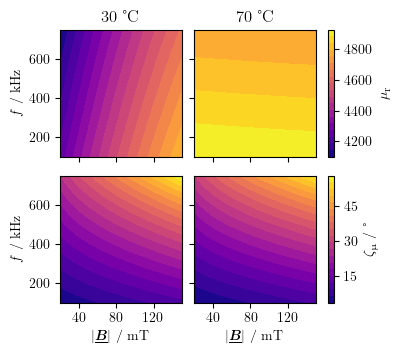

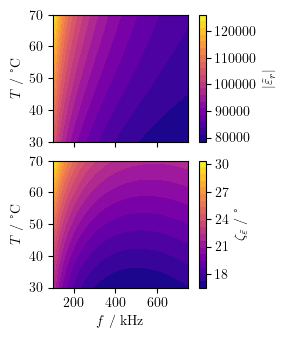

Data exported to N:\groups\lea\data\Employees\tpiepe\Simulationen\TPEL26\materials


In [31]:
material_name = mdb.Material.N95
probe_codes = ["R29.5x19x14.9"]
permeability_data_source = mdb.DataSource.LEA_MTB
permittivity_data_source = mdb.DataSource.LEA_MTB

# set limits to restrict the used fit data
f_min = 100e3
f_max = 750e3

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            f_min_measurement=f_min,
                                            f_max_measurement=f_max,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 70],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    print(f"Data exported to {path2grid_export}")

INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permeability\LEA_MTB\3F46.csvfor the probe codes ['R25x15x10'].
c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:142: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))
INFO:[ 1.00455582e+00  2.13015920e+00  1.72172703e+03  5.13709857e-10
  1.84512608e+00 -2.27161166e+01 -2.06648670e-01  6.47772206e-03]
INFO:MRE = 0.12006306783064791
INFO:Complex data read from C:\Users\tpiepe\Repositories\materialdatabase\materialdatabase\data\complex_permittivity\LEA_MTB\3F46.csv.


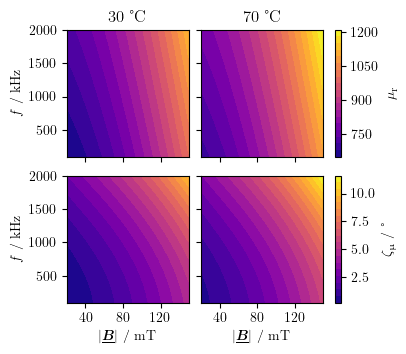

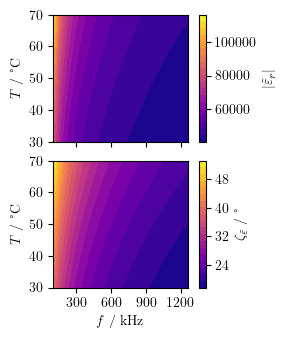

Data exported to N:\groups\lea\data\Employees\tpiepe\Simulationen\TPEL26\materials


In [32]:
material_name = mdb.Material._3F46
probe_codes = ["R25x15x10"]
permeability_data_source = mdb.DataSource.LEA_MTB
permittivity_data_source = mdb.DataSource.LEA_MTB

# set limits to restrict the used fit data
f_min = 100e3
f_max = 2000e3

# Permeability
permeability = mdb_data.get_complex_permeability(material=material_name,
                                                 data_source=permeability_data_source,
                                                 pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                 probe_codes=probe_codes)
df_permeability_grid = permeability.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            grid_flux_density=np.linspace(0, 0.2, 100),
                                            f_min_measurement=None,
                                            f_max_measurement=None,
                                            T_min_measurement=None,
                                            T_max_measurement=None,
                                            b_min_measurement=None,
                                            b_max_measurement=None)

# Permittivity
permittivity = mdb_data.get_complex_permittivity(material=material_name,
                                                 data_source=permittivity_data_source)
df_permittivity_grid = permittivity.to_grid(grid_frequency=np.linspace(f_min, f_max, 50),
                                            grid_temperature=np.linspace(30, 70, 20),
                                            f_min_measurement=f_min,
                                            f_max_measurement=f_max,
                                            T_min_measurement=None,
                                            T_max_measurement=None)


if plot:
    # Permeability
    link2permeability_plot = path2grid_plot.joinpath(f"{material_name.value}_"
                                                     f"{permeability_data_source.value}_permeability_grid.pdf")
    permeability.plot_grid(df_permeability_grid,
                           save_path=link2permeability_plot,
                           temps=[30, 70],
                           no_levels=20,
                           f_min=f_min, f_max=f_max,
                           b_min=20e-3, b_max=150e-3)

    # Permittivity
    link2permittivity_plot = (path2grid_plot.joinpath(f"{material_name.value}_"
                                                      f"{permittivity_data_source.value}_permittivity_grid.pdf"))
    permittivity.plot_grid(df_permittivity_grid,
                           no_levels=20,
                           save_path=link2permittivity_plot,
                           f_min=1e5, f_max=1.3e6)

if save_to_file:
    # Permeability
    link2permeability_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permeability_data_source.value}_permeability_grid.txt")
    permeability.grid2txt(df_permeability_grid, link2permeability_grid)

    # Permittivity
    link2permittivity_grid = path2grid_export.joinpath(f"{material_name.value}_"
                                                       f"{permittivity_data_source.value}_permittivity_grid.txt")
    permittivity.grid2txt(df_permittivity_grid, link2permittivity_grid)

    print(f"Data exported to {path2grid_export}")